# Diffusion Model Training (next-day conditional)

Train a conditional diffusion model that learns the next-day IV surface
distribution given the current-day surface,

- historical: consecutive trading days from the chronologically-ordered
  training slice.
- heston / sabr: consecutive simulation steps within paths assigned
  to the training split (paths are disjoint between train and validation).

- Transformer backbone


In [1]:
import json
import time
from pathlib import Path

import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from implied_volatility_diffusion import (
    ArbitragePenalty,
    ArbitrageWeights,
    DiffusionLoss,
    DiffusionLossConfig,
    DiffusionModel,
    UnifiedGrid,
    GridTransformer,
    VPNoiseScheduler,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "axes.grid": False})


def _select_device() -> torch.device:
    """Prefer Apple Silicon MPS, then CUDA, then CPU."""
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


DEVICE = _select_device()
print(f"compute device: {DEVICE}")


compute device: cuda


In [2]:
%cd ../..


../..


In [3]:
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CFG_DIR = REPO_ROOT / "config"
DATASET_ROOT = REPO_ROOT / "data/processed/forecasting_dataset"
# CHECKPOINT_DIR = REPO_ROOT / "data" / "processed" / "checkpoints"
# CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

GRID = UnifiedGrid.load(CFG_DIR / "unified_iv_grid.yaml")
print("unified grid:", GRID.shape)

if not (DATASET_ROOT / "manifest.json").exists():
    raise FileNotFoundError(
        f"missing {DATASET_ROOT / 'manifest.json'}; "
        "run notebooks/unified_surface_pipeline.ipynb first to materialise the training pool"
    )

unified grid: (41, 40)


##  Load training and validation pair stacks



In [4]:
manifest = json.loads((DATASET_ROOT / "manifest.json").read_text())
print("dataset manifest:", json.dumps(manifest, indent=2))


dataset manifest: {
  "sample_date": "2021-06-17",
  "grid": {
    "shape": [
      41,
      40
    ],
    "config": "config/unified_iv_grid.yaml"
  },
  "normalizers": {
    "historic": {
      "path": "data/processed/forecasting_dataset/normalizers/historic.npz",
      "fit_on": "training",
      "n_train_surfaces": 999
    },
    "heston": {
      "path": "data/processed/forecasting_dataset/normalizers/heston.npz",
      "fit_on": "training",
      "n_train_surfaces": 2300
    },
    "sabr": {
      "path": "data/processed/forecasting_dataset/normalizers/sabr.npz",
      "fit_on": "training",
      "n_train_surfaces": 5520
    }
  },
  "sources": {
    "historical": "data/processed/forecasting_dataset/historical",
    "heston": "data/processed/forecasting_dataset/heston",
    "sabr": "data/processed/forecasting_dataset/sabr"
  },
  "splits": {
    "train": "data/processed/forecasting_dataset/training",
    "val": "data/processed/forecasting_dataset/validation",
    "task": "next_da

In [5]:
TRAIN_DIR = DATASET_ROOT / "training"
VAL_DIR = DATASET_ROOT / "validation"

In [6]:
# TRAIN_DIR = REPO_ROOT / manifest["splits"]["train"]
# VAL_DIR = REPO_ROOT / manifest["splits"]["val"]
normalizer_stats = np.load(DATASET_ROOT / "normalizer.npz")
normalizer_mean = normalizer_stats["mean"].astype(np.float32)
normalizer_std = normalizer_stats["std"].astype(np.float32)
normalizer_iv_floor = float(normalizer_stats.get("iv_floor", 1e-8))
normalizer_stats.close()


#  Training pair stack
pair_curr = np.load(DATASET_ROOT / "training/pair_curr.npy").astype(np.float32)  # S_t
pair_next = np.load(DATASET_ROOT / "training/pair_next.npy").astype(np.float32)  # S_{t+1}
training_sources = np.load(DATASET_ROOT / "training/pair_sources.npy")
assert pair_curr.shape == pair_next.shape, f"train curr/next shape mismatch: {pair_curr.shape} vs {pair_next.shape}"
n_total = int(pair_curr.shape[0])

#  Validation pair stack (held out, not used to update weights)
val_pair_curr = np.load(DATASET_ROOT / "validation/pair_curr.npy").astype(np.float32)
val_pair_next = np.load(DATASET_ROOT / "validation/pair_next.npy").astype(np.float32)
val_pair_sources = np.load(DATASET_ROOT / "validation/pair_sources.npy")
assert val_pair_curr.shape == val_pair_next.shape


historic_surfaces = np.load(DATASET_ROOT / "historical/surfaces.npy")
heston_surfaces = np.load(DATASET_ROOT / "heston/surfaces.npy")  # (n_paths, n_steps, K, T)
sabr_surfaces = np.load(DATASET_ROOT / "sabr/surfaces.npy")  # (n_paths, n_steps, K, T)

historic_dates = pd.DatetimeIndex(np.load(DATASET_ROOT / "historical/dates.npy"))
val_hist_curr_dates = pd.DatetimeIndex(np.load(DATASET_ROOT / "validation/historical_curr_dates.npy"))
val_hist_next_dates = pd.DatetimeIndex(np.load(DATASET_ROOT / "validation/historical_next_dates.npy"))

## Trainig config

In [7]:
NUM_EPOCHS = 30
BATCH_SIZE = 32
LR = 2e-4
GRAD_CLIP = 1.0

SCHEDULER_TIMESTEPS = 400
ARBITRAGE_LAMBDA = 0.05
ARBITRAGE_SCHEDULE = "alpha_bar"

SMOOTHNESS_LAMBDA = 1e-3
SMOOTHNESS_SCHEDULE = "alpha_bar"
EPS_LOSS_SCHEDULE = "alpha_bar"
TIMESTEP_SAMPLING = "uniform"

SEED = 42


WEIGHT_DECAY = 1e-2
WARMUP_FRAC = 0.03
LR_FLOOR_FRAC = 0.05
EMA_DECAY = 0.999
EMA_WARMUP_STEPS = 100
VAL_FRAC = 0.20
VAL_BATCH_CAP = 1024
STRATIFIED_BATCHES = True
INPUT_NOISE_STD_Z = 0.0
LOG_EVERY_N_STEPS = 50

TRANSFORMER_KWARGS = dict(
    grid_shape=tuple(GRID.shape),
    in_channels=1,
    out_channels=1,
    cond_channels=1,
    d_model=128,
    nhead=8,
    layers=8,
    dim_feedforward=512,
    dropout=0.1,
    time_embedding_dim=128,
)


SPOT_REF = 100.0
RATE_REF = 0.03

SNAPSHOT_T_VALUES = (10, 100, 250, 380)
N_SNAPSHOT_EPOCHS = 4

steps_per_epoch = max(int(np.ceil(n_total / BATCH_SIZE)), 1)
total_steps = NUM_EPOCHS * steps_per_epoch
warmup_steps = max(1, int(round(total_steps * WARMUP_FRAC)))


## Build model, scheduler, loss and optimiser

In [8]:
torch.manual_seed(SEED)

scheduler = VPNoiseScheduler(timesteps=SCHEDULER_TIMESTEPS, beta_schedule="cosine")
backbone = GridTransformer(**TRANSFORMER_KWARGS)
model = DiffusionModel(
    backbone,
    scheduler,
    mean=normalizer_mean,
    std=normalizer_std,
    iv_floor=normalizer_iv_floor,
).to(DEVICE)


penalty = ArbitragePenalty(
    log_moneyness=GRID.log_moneyness,
    tau=GRID.tau,
    spot=SPOT_REF,
    rate=RATE_REF,
    weights=ArbitrageWeights(),
)


loss_fn = DiffusionLoss(
    penalty,
    config=DiffusionLossConfig(
        arbitrage_lambda=ARBITRAGE_LAMBDA,
        arbitrage_schedule=ARBITRAGE_SCHEDULE,
        smoothness_lambda=SMOOTHNESS_LAMBDA,
        smoothness_schedule=SMOOTHNESS_SCHEDULE,
        eps_loss_schedule=EPS_LOSS_SCHEDULE,
        timestep_sampling=TIMESTEP_SAMPLING,
    ),
).to(DEVICE)


src/implied_volatility_diffusion/diffusion/backbones/transformer.py:74: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


In [9]:
def _split_params_for_decay(module: torch.nn.Module) -> tuple[list, list]:
    decay, no_decay = [], []
    for name, p in module.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or name.endswith(".bias"):
            no_decay.append(p)
        else:
            decay.append(p)
    return decay, no_decay


_decay_params, _no_decay_params = _split_params_for_decay(model)
optimizer = torch.optim.AdamW(
    [
        {"params": _decay_params, "weight_decay": WEIGHT_DECAY},
        {"params": _no_decay_params, "weight_decay": 0.0},
    ],
    lr=LR,
    betas=(0.9, 0.999),
    eps=1e-8,
)


def _make_lr_schedule(
    optimizer: torch.optim.Optimizer,
    *,
    total_steps: int,
    warmup_steps: int,
    floor_frac: float,
) -> torch.optim.lr_scheduler.LambdaLR:
    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        progress = min(max(progress, 0.0), 1.0)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return floor_frac + (1.0 - floor_frac) * cosine

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


lr_scheduler = _make_lr_schedule(
    optimizer,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    floor_frac=LR_FLOOR_FRAC,
)


class _EmaShadow:
    """Lightweight EMA over a model's parameters and buffers.

    ``decay`` is the smoothing factor (closer to 1 -> slower averaging).
    Buffers are tracked too so the EMA copy can be loaded directly without
    recomputing per-pixel normalization stats.
    """

    def __init__(
        self,
        module: torch.nn.Module,
        *,
        decay: float = 0.999,
        warmup_steps: int = 0,
    ) -> None:
        self.decay = float(decay)
        self.warmup_steps = int(warmup_steps)
        self._step = 0
        self.shadow_module = copy.deepcopy(module).eval()
        for p in self.shadow_module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, module: torch.nn.Module) -> None:
        self._step += 1
        # Linear warmup of the effective decay so the early shadow tracks the
        # live model (avoids "EMA stuck near init" for the first epoch).
        d = min(self.decay, (self._step + 1) / (self._step + 10)) if self._step <= self.warmup_steps else self.decay
        live_params = dict(module.named_parameters())
        live_buffers = dict(module.named_buffers())
        for name, p_shadow in self.shadow_module.named_parameters():
            p_live = live_params.get(name)
            if p_live is None:
                continue
            p_shadow.data.mul_(d).add_(p_live.data, alpha=1.0 - d)
        for name, b_shadow in self.shadow_module.named_buffers():
            b_live = live_buffers.get(name)
            if b_live is None:
                continue
            if b_shadow.dtype.is_floating_point:
                b_shadow.data.mul_(d).add_(b_live.data, alpha=1.0 - d)
            else:
                b_shadow.data.copy_(b_live.data)


ema = _EmaShadow(model, decay=EMA_DECAY, warmup_steps=EMA_WARMUP_STEPS)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

##  Held-out denoising (conditional)


In [10]:
# select a historical (S_t, S_{t+1}) pair
val_hist_mask = val_pair_sources == 0
val_hist_indices = np.flatnonzero(val_hist_mask)
holdout_val_idx = int(val_hist_indices[-1])

holdout_curr_np = val_pair_curr[holdout_val_idx].astype(np.float32)
holdout_next_np = val_pair_next[holdout_val_idx].astype(np.float32)

holdout_curr = torch.tensor(holdout_curr_np, dtype=torch.float32, device=DEVICE)[None, None]
holdout_next = torch.tensor(holdout_next_np, dtype=torch.float32, device=DEVICE)[None, None]

In [11]:
# Translate the val_hist row index to the underlying historical date pair.
hist_val_pos = int(np.searchsorted(val_hist_indices, holdout_val_idx))
holdout_curr_date = val_hist_curr_dates[hist_val_pos]
holdout_next_date = val_hist_next_dates[hist_val_pos]
snapshot_t = torch.tensor(SNAPSHOT_T_VALUES, dtype=torch.long, device=DEVICE).clamp(max=scheduler.timesteps - 1)

snapshot_generator = torch.Generator().manual_seed(SEED)
holdout_z0_next = model.normalize(holdout_next)
holdout_cond_z = model.normalize(holdout_curr)
holdout_eps = torch.randn(
    (snapshot_t.shape[0], *holdout_z0_next.shape[1:]),
    generator=snapshot_generator,
).to(DEVICE)
holdout_z_t = scheduler.q_sample(
    holdout_z0_next.expand(snapshot_t.shape[0], -1, -1, -1).contiguous(),
    snapshot_t,
    noise=holdout_eps,
)
holdout_cond_z_batched = holdout_cond_z.expand(snapshot_t.shape[0], -1, -1, -1).contiguous()

epochs_for_snapshots = sorted(set(int(round(v)) for v in np.linspace(1, NUM_EPOCHS, N_SNAPSHOT_EPOCHS).tolist()))
print(f"snapshot epochs: {epochs_for_snapshots}")
print(f"snapshot timesteps: {snapshot_t.tolist()}")

snapshot epochs: [1, 11, 20, 30]
snapshot timesteps: [10, 100, 250, 380]


## Model training

In [12]:
training_tensor_next = torch.from_numpy(pair_next).unsqueeze(1)
training_tensor_curr = torch.from_numpy(pair_curr).unsqueeze(1)
PIN_MEMORY = DEVICE.type == "cuda"
if PIN_MEMORY:
    training_tensor_next = training_tensor_next.pin_memory()
    training_tensor_curr = training_tensor_curr.pin_memory()

#   - Train / val split (stratified by source)
val_rng = np.random.default_rng(SEED + 999)
val_idx_list: list[np.ndarray] = []
for src_id in np.unique(training_sources):
    where = np.flatnonzero(training_sources == src_id)
    n_val_src = max(1, int(round(len(where) * VAL_FRAC))) if VAL_FRAC > 0 else 0
    if n_val_src > 0:
        chosen = val_rng.choice(where, size=n_val_src, replace=False)
        val_idx_list.append(chosen)
val_indices = np.sort(np.concatenate(val_idx_list)) if val_idx_list else np.empty(0, dtype=np.int64)
val_mask = np.zeros(n_total, dtype=bool)
val_mask[val_indices] = True
train_indices = np.flatnonzero(~val_mask)
train_sources_ = training_sources[train_indices]
n_train = int(train_indices.shape[0])
n_val = int(val_indices.shape[0])
print(f"train/val split: train={n_train}  val={n_val}  (val_frac={VAL_FRAC})")

src_buckets: dict[int, np.ndarray] = {
    int(src): train_indices[np.flatnonzero(train_sources_ == src)] for src in np.unique(train_sources_)
}
src_quotas = {
    src_id: max(1, int(round(BATCH_SIZE * len(idxs) / max(1, n_train)))) for src_id, idxs in src_buckets.items()
}


def _stratified_batch_indices(rng_: np.random.Generator) -> np.ndarray:
    """Sample one batch with per-source quotas (with replacement within source)."""
    chunks: list[np.ndarray] = []
    for src_id, idxs in src_buckets.items():
        if idxs.size == 0:
            continue
        chunks.append(
            rng_.choice(idxs, size=src_quotas[src_id], replace=False if idxs.size >= src_quotas[src_id] else True)
        )
    if not chunks:
        return np.empty(0, dtype=np.int64)
    return np.concatenate(chunks)


arb_family_names = ["calendar", "butterfly", "call"]

step_history: dict[str, list[float | int]] = {
    "step": [],
    "epoch": [],
    "loss": [],
    "loss_eps": [],
    "loss_smooth": [],
    "loss_arb": [],
    "grad_norm": [],
    "lr": [],
    "arb_weight_mean": [],
    "skipped_nonfinite": [],
}
for name in arb_family_names:
    step_history[f"arb_{name}"] = []

epoch_history: list[dict[str, float]] = []
snapshots: list[dict[str, np.ndarray | int]] = []


def _validation_loss(model_to_eval: torch.nn.Module) -> dict[str, float]:
    """Mean eps MSE + smoothness + arbitrage on the held-out validation slice."""
    if n_val == 0:
        return {
            "val_loss": float("nan"),
            "val_loss_eps": float("nan"),
            "val_loss_smooth": float("nan"),
            "val_loss_arb": float("nan"),
        }
    val_rng_local = torch.Generator().manual_seed(SEED + 1234)
    chunks: list[dict[str, float]] = []
    model_to_eval.eval()
    with torch.no_grad():
        for vb_start in range(0, n_val, BATCH_SIZE):
            v_idx = val_indices[vb_start : vb_start + BATCH_SIZE]
            v_iv_next = training_tensor_next[v_idx].to(DEVICE, non_blocking=PIN_MEMORY)
            v_iv_curr = training_tensor_curr[v_idx].to(DEVICE, non_blocking=PIN_MEMORY)
            v_cond_z = model_to_eval.normalize(v_iv_curr)
            v_t = loss_fn.sample_timesteps(
                v_iv_next.shape[0],
                scheduler,
                device=DEVICE,
                generator=val_rng_local,
            )
            v_noise = torch.randn(v_iv_next.shape, generator=val_rng_local).to(DEVICE)
            v_out = loss_fn(model_to_eval, v_iv_next, t=v_t, noise=v_noise, cond=v_cond_z)
            chunks.append(
                {
                    "loss": float(v_out["loss"].detach()),
                    "loss_eps": float(v_out["loss_eps"].detach()),
                    "loss_smooth": float(v_out.get("loss_smooth", torch.zeros(1)).detach()),
                    "loss_arb": float(v_out.get("loss_arb", torch.zeros(1)).detach()),
                    "n": v_iv_next.shape[0],
                }
            )
    if not chunks:
        return {
            "val_loss": float("nan"),
            "val_loss_eps": float("nan"),
            "val_loss_smooth": float("nan"),
            "val_loss_arb": float("nan"),
        }
    total_n = sum(c["n"] for c in chunks)
    return {
        "val_loss": sum(c["loss"] * c["n"] for c in chunks) / total_n,
        "val_loss_eps": sum(c["loss_eps"] * c["n"] for c in chunks) / total_n,
        "val_loss_smooth": sum(c["loss_smooth"] * c["n"] for c in chunks) / total_n,
        "val_loss_arb": sum(c["loss_arb"] * c["n"] for c in chunks) / total_n,
    }

train/val split: train=6999  val=1750  (val_frac=0.2)


train model

In [13]:
steps_per_epoch_train = max(int(np.ceil(n_train / BATCH_SIZE)), 1)
total_steps_train = NUM_EPOCHS * steps_per_epoch_train

rng = np.random.default_rng(SEED)
global_step = 0
nonfinite_skips = 0
best_val = float("inf")
best_state = None
best_epoch = 0
model.train()
t0 = time.perf_counter()

epoch_progress = tqdm(range(1, NUM_EPOCHS + 1), desc="Training epochs", unit="epoch")
for epoch in epoch_progress:
    perm = rng.permutation(n_train)
    epoch_losses: list[float] = []
    epoch_loss_eps: list[float] = []
    epoch_loss_smooth: list[float] = []
    epoch_loss_arb: list[float] = []
    epoch_skipped = 0
    batch_progress = tqdm(
        range(0, n_train, BATCH_SIZE),
        desc=f"Epoch {epoch}/{NUM_EPOCHS}",
        unit="batch",
        leave=False,
    )
    for batch_start in batch_progress:
        if STRATIFIED_BATCHES:
            idx = _stratified_batch_indices(rng)
        else:
            idx = train_indices[perm[batch_start : batch_start + BATCH_SIZE]]
        if idx.size == 0:
            continue
        batch_iv_next = training_tensor_next[idx].to(DEVICE, non_blocking=PIN_MEMORY)
        batch_iv_curr = training_tensor_curr[idx].to(DEVICE, non_blocking=PIN_MEMORY)
        with torch.no_grad():
            cond_z = model.normalize(batch_iv_curr)

        # Optional small jitter in *normalized* target space simulates calibration
        # noise and acts as input dropout regularisation.
        if INPUT_NOISE_STD_Z > 0.0:
            with torch.no_grad():
                z_clean = model.normalize(batch_iv_next)
                z_jit = z_clean + INPUT_NOISE_STD_Z * torch.randn_like(z_clean)
                batch_iv_next = model.denormalize(z_jit)

        optimizer.zero_grad(set_to_none=True)
        out = loss_fn(model, batch_iv_next, cond=cond_z)
        loss_value = out["loss"]

        if not torch.isfinite(loss_value):
            optimizer.zero_grad(set_to_none=True)
            nonfinite_skips += 1
            epoch_skipped += 1
            global_step += 1
            lr_scheduler.step()
            continue

        loss_value.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        if not torch.isfinite(grad_norm):
            optimizer.zero_grad(set_to_none=True)
            nonfinite_skips += 1
            epoch_skipped += 1
            global_step += 1
            lr_scheduler.step()
            continue

        optimizer.step()
        lr_scheduler.step()
        ema.update(model)

        step_loss = float(out["loss"].detach())
        step_loss_eps = float(out["loss_eps"].detach())
        step_loss_smooth = float(out.get("loss_smooth", torch.zeros(1)).detach())
        step_loss_arb = float(out.get("loss_arb", torch.zeros(1)).detach())
        cur_lr = float(optimizer.param_groups[0]["lr"])

        step_history["step"].append(global_step)
        step_history["epoch"].append(epoch)
        step_history["loss"].append(step_loss)
        step_history["loss_eps"].append(step_loss_eps)
        step_history["loss_smooth"].append(step_loss_smooth)
        step_history["loss_arb"].append(step_loss_arb)
        step_history["grad_norm"].append(float(grad_norm))
        step_history["lr"].append(cur_lr)
        step_history["arb_weight_mean"].append(float(out.get("arb_weight_mean", torch.zeros(1)).detach()))
        step_history["skipped_nonfinite"].append(0)
        for name in arb_family_names:
            step_history[f"arb_{name}"].append(float(out.get(f"arb_{name}", torch.zeros(1)).detach()))

        epoch_losses.append(step_loss)
        epoch_loss_eps.append(step_loss_eps)
        epoch_loss_smooth.append(step_loss_smooth)
        epoch_loss_arb.append(step_loss_arb)
        global_step += 1

        if LOG_EVERY_N_STEPS > 0 and (global_step % LOG_EVERY_N_STEPS == 0):
            print(
                f"    step {global_step:>5d}  loss={step_loss:.4f}  "
                f"eps={step_loss_eps:.4f}  smth={step_loss_smooth:.4f}  arb={step_loss_arb:.4f}  "
                f"grad={float(grad_norm):.3f}  lr={cur_lr:.2e}"
            )

    val_metrics = _validation_loss(ema.shadow_module if EMA_DECAY > 0 else model)
    model.train()

    epoch_summary = {
        "epoch": epoch,
        "loss_mean": float(np.mean(epoch_losses)) if epoch_losses else float("nan"),
        "loss_eps_mean": float(np.mean(epoch_loss_eps)) if epoch_loss_eps else float("nan"),
        "loss_smooth_mean": float(np.mean(epoch_loss_smooth)) if epoch_loss_smooth else float("nan"),
        "loss_arb_mean": float(np.mean(epoch_loss_arb)) if epoch_loss_arb else float("nan"),
        "skipped_nonfinite_epoch": int(epoch_skipped),
        "elapsed_s": time.perf_counter() - t0,
        **val_metrics,
    }
    epoch_history.append(epoch_summary)
    epoch_progress.set_postfix(
        loss=f"{epoch_summary['loss_mean']:.4f}",
        val=f"{epoch_summary['val_loss']:.4f}",
        skip=int(epoch_skipped),
    )
    print(
        f"  epoch {epoch:>2d}/{NUM_EPOCHS}  "
        f"loss={epoch_summary['loss_mean']:.4f}  "
        f"eps={epoch_summary['loss_eps_mean']:.4f}  "
        f"smth={epoch_summary['loss_smooth_mean']:.4f}  "
        f"arb={epoch_summary['loss_arb_mean']:.4f}  "
        f"val={epoch_summary['val_loss']:.4f}  "
        f"skip={epoch_skipped}  "
        f"({epoch_summary['elapsed_s']:.0f}s)"
    )

    if n_val > 0 and np.isfinite(val_metrics["val_loss"]) and val_metrics["val_loss"] < best_val:
        best_val = float(val_metrics["val_loss"])
        best_epoch = epoch
        best_state = copy.deepcopy(ema.shadow_module.state_dict())

    if epoch in epochs_for_snapshots:
        eval_module = ema.shadow_module if EMA_DECAY > 0 else model
        eval_module.eval()
        with torch.no_grad():
            iv_pred = eval_module.predict_iv(holdout_z_t, snapshot_t, holdout_cond_z_batched)
        snapshots.append(
            {
                "epoch": epoch,
                "step": global_step,
                "iv_pred": iv_pred.squeeze(1).cpu().numpy(),
            }
        )
        model.train()

if best_state is not None:
    print(f"loading best EMA checkpoint from epoch {best_epoch} (val_loss={best_val:.4f})")
    model.load_state_dict(best_state)
elif EMA_DECAY > 0:
    print("loading final EMA checkpoint into the live model.")
    model.load_state_dict(ema.shadow_module.state_dict())


Training epochs:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1/30:   0%|          | 0/219 [00:00<?, ?batch/s]

    step    50  loss=0.0721  eps=0.0510  smth=0.3883  arb=0.4146  grad=0.664  lr=4.13e-05
    step   100  loss=0.0332  eps=0.0149  smth=0.2686  arb=0.3608  grad=0.490  lr=8.18e-05
    step   150  loss=0.0391  eps=0.0214  smth=0.2707  arb=0.3496  grad=0.991  lr=1.22e-04
    step   200  loss=0.0313  eps=0.0125  smth=0.2230  arb=0.3723  grad=0.226  lr=1.63e-04
  epoch  1/30  loss=0.0777  eps=0.0550  smth=0.3828  arb=0.4458  val=0.0386  skip=0  (453s)


Epoch 2/30:   0%|          | 0/219 [00:00<?, ?batch/s]

    step   250  loss=0.0255  eps=0.0135  smth=0.0636  arb=0.2396  grad=0.149  lr=2.00e-04
    step   300  loss=0.0207  eps=0.0118  smth=0.0455  arb=0.1776  grad=0.450  lr=2.00e-04
    step   350  loss=0.0184  eps=0.0102  smth=0.0375  arb=0.1628  grad=0.601  lr=2.00e-04
    step   400  loss=0.0143  eps=0.0064  smth=0.0322  arb=0.1591  grad=0.212  lr=2.00e-04
  epoch  2/30  loss=0.0235  eps=0.0118  smth=0.0833  arb=0.2316  val=0.0358  skip=0  (909s)


...

    step  5950  loss=0.0201  eps=0.0099  smth=0.1184  arb=0.2012  grad=0.191  lr=4.55e-05
    step  6000  loss=0.0133  eps=0.0046  smth=0.0276  arb=0.1724  grad=0.068  lr=4.41e-05
    step  6050  loss=0.0227  eps=0.0108  smth=0.0923  arb=0.2348  grad=0.032  lr=4.27e-05
    step  6100  loss=0.0131  eps=0.0050  smth=0.0267  arb=0.1617  grad=0.045  lr=4.13e-05
  epoch 28/30  loss=0.0162  eps=0.0069  smth=0.0508  arb=0.1863  val=0.0158  skip=0  (12773s)


Epoch 29/30:   0%|          | 0/219 [00:00<?, ?batch/s]

    step  6150  loss=0.0112  eps=0.0043  smth=0.0242  arb=0.1382  grad=0.036  lr=3.99e-05
    step  6200  loss=0.0170  eps=0.0079  smth=0.0350  arb=0.1814  grad=0.045  lr=3.85e-05
    step  6250  loss=0.0190  eps=0.0090  smth=0.0420  arb=0.1988  grad=0.042  lr=3.72e-05
    step  6300  loss=0.0168  eps=0.0059  smth=0.0311  arb=0.2182  grad=0.020  lr=3.59e-05
    step  6350  loss=0.0161  eps=0.0065  smth=0.0472  arb=0.1906  grad=0.024  lr=3.46e-05
  epoch 29/30  loss=0.0165  eps=0.0073  smth=0.0424  arb=0.1832  val=0.0157  skip=0  (13229s)


Epoch 30/30:   0%|          | 0/219 [00:00<?, ?batch/s]

    step  6400  loss=0.0202  eps=0.0104  smth=0.0356  arb=0.1956  grad=0.024  lr=3.34e-05
    step  6450  loss=0.0141  eps=0.0064  smth=0.0394  arb=0.1532  grad=0.011  lr=3.22e-05
    step  6500  loss=0.0140  eps=0.0059  smth=0.0425  arb=0.1617  grad=0.021  lr=3.10e-05
    step  6550  loss=0.0192  eps=0.0089  smth=0.0512  arb=0.2046  grad=0.034  lr=2.98e-05
  epoch 30/30  loss=0.0167  eps=0.0074  smth=0.0465  arb=0.1853  val=0.0157  skip=0  (13685s)
loading best EMA checkpoint from epoch 30 (val_loss=0.0157)


In [14]:
step_history_df = pd.DataFrame(step_history)
epoch_history_df = pd.DataFrame(epoch_history)
print(
    f"trained {global_step} steps across {NUM_EPOCHS} epochs in "
    f"{time.perf_counter() - t0:.1f}s  (skipped non-finite={nonfinite_skips})"
)
print(epoch_history_df.to_string(index=False))

trained 6570 steps across 30 epochs in 13684.8s  (skipped non-finite=0)
 epoch  loss_mean  loss_eps_mean  loss_smooth_mean  loss_arb_mean  skipped_nonfinite_epoch    elapsed_s  val_loss  val_loss_eps  val_loss_smooth  val_loss_arb
     1   0.077681       0.055007          0.382761       0.445821                        0   453.311614  0.038571      0.017008         0.358948      0.424077
     2   0.023474       0.011810          0.083338       0.231609                        0   909.307134  0.035773      0.015166         0.327087      0.405599
     3   0.020104       0.009650          0.055251       0.207965                        0  1365.296340  0.032332      0.012914         0.288477      0.382585
     4   0.018305       0.008413          0.042426       0.196994                        0  1821.449381  0.028806      0.010550         0.249129      0.360140
     5   0.018534       0.008706          0.040677       0.195746                        0  2277.571778  0.025660      0.008632      

## plots

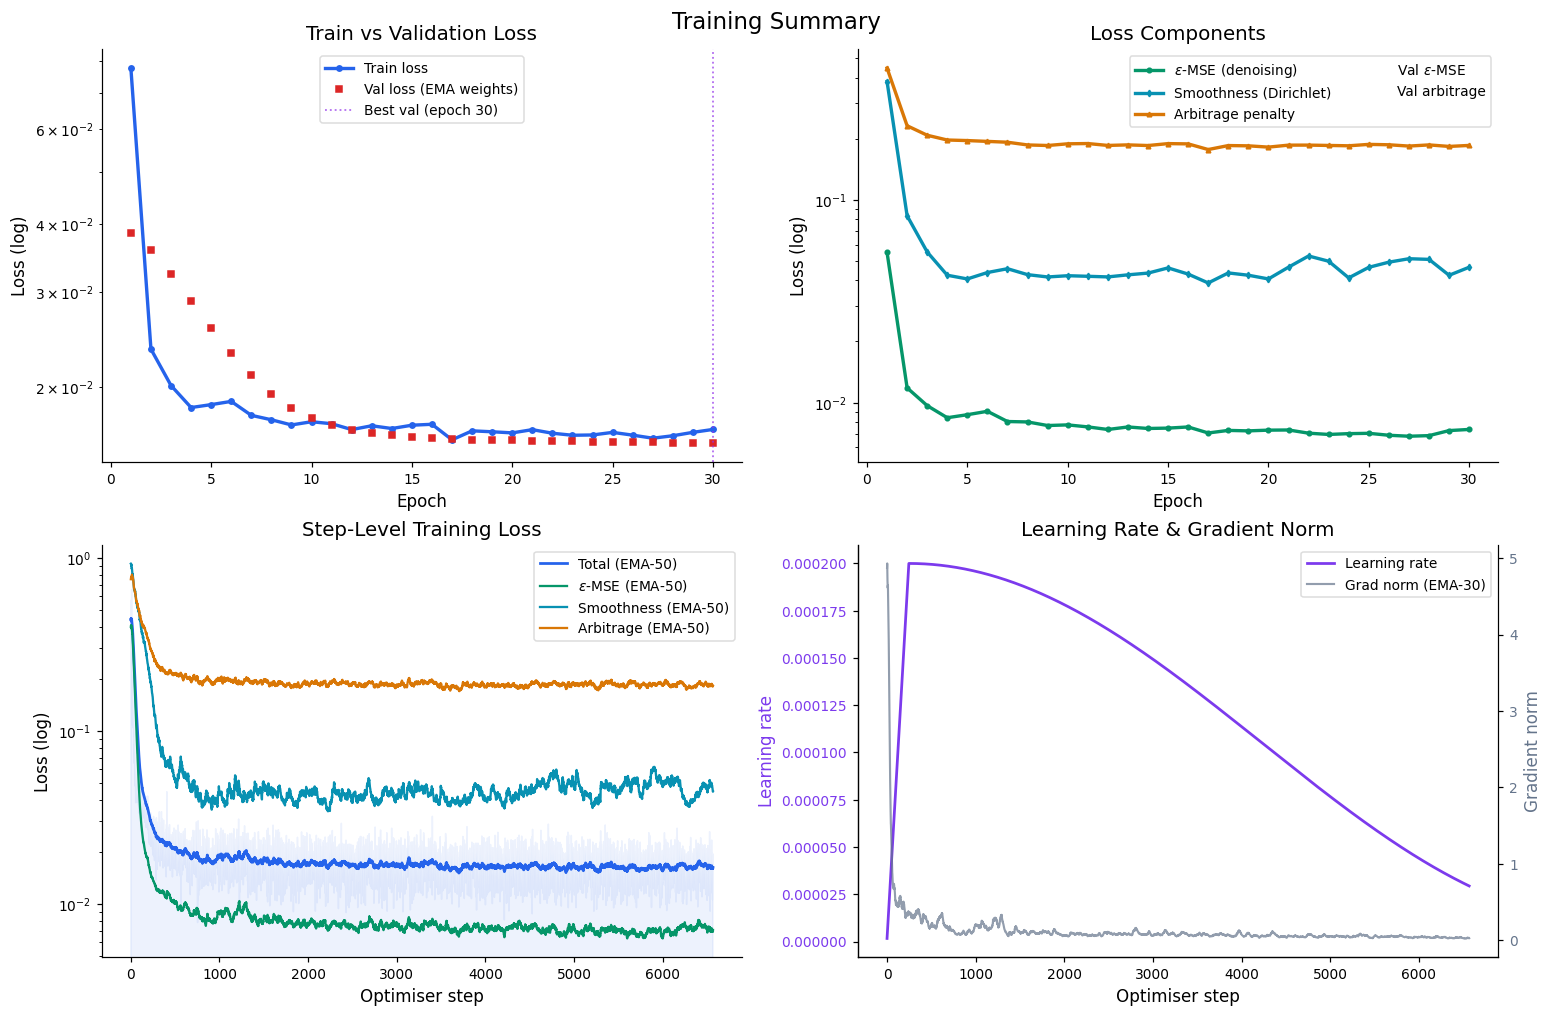

In [15]:
def _ema(series: np.ndarray, span: int = 50) -> np.ndarray:
    return pd.Series(series).ewm(span=span, adjust=False).mean().to_numpy()


_STYLE = {
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "0.85",
}

with plt.rc_context(_STYLE):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    epochs = epoch_history_df["epoch"].to_numpy()
    steps_arr = step_history_df["step"].to_numpy()

    ax = axes[0, 0]
    ax.plot(
        epochs, epoch_history_df["loss_mean"], lw=2.2, color="#2563eb", marker="o", markersize=3.5, label="Train loss"
    )
    if "val_loss" in epoch_history_df.columns and epoch_history_df["val_loss"].notna().any():
        ax.plot(
            epochs,
            epoch_history_df["val_loss"],
            lw=2.2,
            color="#dc2626",
            marker="s",
            markersize=3.5,
            linestyle=" ",
            label="Val loss (EMA weights)",
        )
    if best_epoch > 0:
        ax.axvline(best_epoch, color="#9333ea", ls=":", lw=1.2, alpha=0.7, label=f"Best val (epoch {best_epoch})")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Train vs Validation Loss")
    ax.legend()
    ax.grid(alpha=0.15, which="both", ls=" ")

    ax = axes[0, 1]
    ax.plot(
        epochs,
        epoch_history_df["loss_eps_mean"],
        lw=2.2,
        color="#059669",
        marker="o",
        markersize=3,
        label=r"$\epsilon$-MSE (denoising)",
    )
    ax.plot(
        epochs,
        epoch_history_df["loss_smooth_mean"],
        lw=2.2,
        color="#0891b2",
        marker="d",
        markersize=3,
        label="Smoothness (Dirichlet)",
    )
    ax.plot(
        epochs,
        epoch_history_df["loss_arb_mean"],
        lw=2.2,
        color="#d97706",
        marker="^",
        markersize=3,
        label="Arbitrage penalty",
    )
    if "val_loss_eps" in epoch_history_df.columns:
        ax.plot(
            epochs,
            epoch_history_df["val_loss_eps"],
            lw=1.6,
            color="#059669",
            ls=" ",
            alpha=0.65,
            label=r"Val $\epsilon$-MSE",
        )
    if "val_loss_arb" in epoch_history_df.columns:
        ax.plot(
            epochs,
            epoch_history_df["val_loss_arb"],
            lw=1.6,
            color="#d97706",
            ls=" ",
            alpha=0.65,
            label="Val arbitrage",
        )
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Loss Components")
    ax.legend(ncols=2)
    ax.grid(alpha=0.15, which="both", ls=" ")

    ax = axes[1, 0]
    ax.fill_between(steps_arr, step_history_df["loss"], alpha=0.08, color="#2563eb")
    ax.plot(steps_arr, _ema(step_history_df["loss"].to_numpy()), lw=1.8, color="#2563eb", label="Total (EMA-50)")
    ax.plot(
        steps_arr,
        _ema(step_history_df["loss_eps"].to_numpy()),
        lw=1.5,
        color="#059669",
        label=r"$\epsilon$-MSE (EMA-50)",
    )
    ax.plot(
        steps_arr,
        _ema(step_history_df["loss_smooth"].to_numpy()),
        lw=1.5,
        color="#0891b2",
        label="Smoothness (EMA-50)",
    )
    ax.plot(
        steps_arr, _ema(step_history_df["loss_arb"].to_numpy()), lw=1.5, color="#d97706", label="Arbitrage (EMA-50)"
    )
    ax.set_yscale("log")
    ax.set_xlabel("Optimiser step")
    ax.set_ylabel("Loss (log)")
    ax.set_title("Step-Level Training Loss")
    ax.legend()
    ax.grid(alpha=0.15, which="both", ls=" ")

    ax = axes[1, 1]
    color_lr, color_gn = "#7c3aed", "#64748b"
    ax.plot(steps_arr, step_history_df["lr"], lw=1.8, color=color_lr, label="Learning rate")
    ax.set_xlabel("Optimiser step")
    ax.set_ylabel("Learning rate", color=color_lr)
    ax.tick_params(axis="y", labelcolor=color_lr)
    ax.grid(alpha=0.15, which="both", ls=" ")

    ax2 = ax.twinx()
    ax2.plot(
        steps_arr,
        _ema(step_history_df["grad_norm"].to_numpy(), span=30),
        lw=1.4,
        color=color_gn,
        alpha=0.7,
        label="Grad norm (EMA-30)",
    )
    ax2.set_ylabel("Gradient norm", color=color_gn)
    ax2.tick_params(axis="y", labelcolor=color_gn)
    ax2.spines["right"].set_visible(True)
    ax2.spines["top"].set_visible(False)
    ax.set_title("Learning Rate & Gradient Norm")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    fig.suptitle("Training Summary", fontsize=15, y=1.01)
    fig.savefig("training_loss_curves.pdf", format="pdf", bbox_inches="tight")
    plt.show()

## Save checkpoint

Persist the trained weights, optimiser state, loss histories

In [16]:
CHECKPOINT_DIR = REPO_ROOT / "data/processed/checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
checkpoint_path = CHECKPOINT_DIR / "transformer.pt"
config_path = CHECKPOINT_DIR / "training_config.json"
step_csv_path = CHECKPOINT_DIR / "training_step_history.csv"
epoch_csv_path = CHECKPOINT_DIR / "training_epoch_history.csv"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_timesteps": SCHEDULER_TIMESTEPS,
        "backbone": "grid_transformer",
        "transformer_kwargs": TRANSFORMER_KWARGS,
        "grid_shape": tuple(GRID.shape),
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "arbitrage_lambda": ARBITRAGE_LAMBDA,
        "arbitrage_schedule": ARBITRAGE_SCHEDULE,
        "smoothness_lambda": SMOOTHNESS_LAMBDA,
        "smoothness_schedule": SMOOTHNESS_SCHEDULE,
        "spot_ref": SPOT_REF,
        "rate_ref": RATE_REF,
        "seed": SEED,
        "conditional": True,
        "cond_channels": int(TRANSFORMER_KWARGS.get("cond_channels", 0)),
        "prediction_type": model.prediction_type,
        "eps_loss_schedule": EPS_LOSS_SCHEDULE,
    },
    checkpoint_path,
)
config_path.write_text(
    json.dumps(
        {
            "num_epochs": NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "scheduler_timesteps": SCHEDULER_TIMESTEPS,
            "arbitrage_lambda": ARBITRAGE_LAMBDA,
            "arbitrage_schedule": ARBITRAGE_SCHEDULE,
            "smoothness_lambda": SMOOTHNESS_LAMBDA,
            "smoothness_schedule": SMOOTHNESS_SCHEDULE,
            "eps_loss_schedule": EPS_LOSS_SCHEDULE,
            "prediction_type": model.prediction_type,
            "timestep_sampling": TIMESTEP_SAMPLING,
            "backbone": "grid_transformer",
            "transformer_kwargs": TRANSFORMER_KWARGS,
            "grid_shape": list(GRID.shape),
            "training_pool_size": int(n_total),
            "spot_ref": SPOT_REF,
            "rate_ref": RATE_REF,
            "holdout_curr_date": str(holdout_curr_date.date()),
            "holdout_next_date": str(holdout_next_date.date()),
            "snapshot_t": list(snapshot_t.tolist()),
            "epochs_for_snapshots": list(epochs_for_snapshots),
            "seed": SEED,
            "conditional": True,
        },
        indent=2,
    ),
    encoding="utf-8",
)
step_history_df.to_csv(step_csv_path, index=False)
epoch_history_df.to_csv(epoch_csv_path, index=False)

print(f"saved checkpoint: {checkpoint_path.relative_to(REPO_ROOT)}")
print(f"saved config : {config_path.relative_to(REPO_ROOT)}")
print(f"saved step log : {step_csv_path.relative_to(REPO_ROOT)}")
print(f"saved epoch log : {epoch_csv_path.relative_to(REPO_ROOT)}")


saved checkpoint: transformer.pt
saved config : training_config.json
saved step log : training_step_history.csv
saved epoch log : training_epoch_history.csv
